In [2]:
import numpy as np
import pandas as pd
from pathlib import Path

from loader.parser import *
from loader.load import trace_dir, gather_traces_by_query, iter_trino_dags_with_id, align_plans_and_runs
from prediction.trinoNumericQueryEncoder import TrinoNumericPlanEncoder, trino_dag_dict_to_nx, trino_graph_structural_features, canon_qid

from prediction.trinoGraphQueryEncoder import TrinoGraphWLPlanEncoder

from prediction.model import ConditionalTraceRuntimeModel
from prediction.heads import *
from prediction.evaluate import evaluate_unseen_queries, evaluate_global_baseline_on_test
from prediction.plot import plot_query_diagnostics

from prediction.config import *

In [3]:

"""
Set query configs
"""

collection = "tpcds_500"
instance = "lakehouse-a"
schema = "tpcds"

run_ids = list([
    "20260222-191819Z",
    "20260223-161227Z",
    "20260224-125456Z",
    "20260225-095819Z",
    "20260226-065736Z",
])

In [4]:

"""
Load and extract query plans and features
"""
# any set of plans is fine here (... assuming that plans are identical across runs)
queries_dir = "/mnt/lakehouse-raw-results/tpcds/lakehouse-a/20260222-191819Z/queries"

plans_by_query = {}
for qid, dag in iter_trino_dags_with_id(queries_dir):
    plans_by_query[qid] = dag

print(len(plans_by_query.keys()))

"""
Load and extract traces from query runs
"""
run_dirs = [Path(trace_dir(run_id=run_id,
                           query_name=None,
                           collection=collection,
                           schema=schema,
                           instance=instance,
                          )) for run_id in run_ids]

runs_by_query = gather_traces_by_query(
    run_dirs,
    metric=METRIC,
    xcol=XCOL,
    ycol=YCOL,
)

print(len(plans_by_query.keys()))
print(len(runs_by_query.keys()))

plans_by_query, runs_by_query, common = align_plans_and_runs(
    plans_by_query,
    runs_by_query,
    min_runs=1,
    min_points_per_run=2,
    require_cols=(XCOL, YCOL),
)
print(len(plans_by_query.keys()))
print(len(runs_by_query.keys()))


plans_by_query = {canon_qid(k): v for k, v in plans_by_query.items()}
runs_by_query  = {canon_qid(k): v for k, v in runs_by_query.items()}
common = sorted(set(plans_by_query) & set(runs_by_query))

#visualisation function:     plot_trino_dag_graphviz_spaced(dag, rankdir="RL", ranksep=2.0, nodesep=0.8)

468
468
415
415
415


In [5]:

"""
Split into training and testing sets
"""

rng = np.random.default_rng(SEED)
rng.shuffle(common)

n_test = max(1, int(len(common) * TEST_FRAC))
test_qids = sorted(common[:n_test])
train_qids = sorted(common[n_test:])

print("n_train:", len(train_qids), "n_test:", len(test_qids))

runs_train  = {q: runs_by_query[q]  for q in train_qids}
runs_test   = {q: runs_by_query[q]  for q in test_qids}


n_train: 332 n_test: 83


In [16]:

"""
Generate embeddings Numerical Only
"""

enc = TrinoNumericPlanEncoder.fit_from_train_plans(
    train_plans=[plans_by_query[q] for q in train_qids],
    min_op_freq=1,
    max_vocab=64,          # tune
    include_unk=True,
    include_global=True,
    include_counts=True,
)

Z_train = {q: enc.encode_plan(plans_by_query[q]) for q in train_qids}
Z_test  = {q: enc.encode_plan(plans_by_query[q]) for q in test_qids}
print("z dim:", next(iter(Z_train.values())).shape)


z dim: (379,)


In [17]:

"""
Generate embeddings Graph
"""

# Python
enc = TrinoGraphWLPlanEncoder.fit_from_train_plans(
    train_plans=[plans_by_query[q] for q in train_qids],
    emb_dim=256,           # embedding dimension
    n_iter=4,              # WL iterations
    include_edge_types=True,
    direction="both",       # out, in  both
    standardise=True,      # fit mean/std on train, apply at encode time
    use_estimates=True,    # Use the numerical estimates of the output values for each node
    use_cost_estimates=False, # NEW: Use the predicted CPU, RAM, and Network cost values for each node
    # extra kwargs accepted for compatibility and ignored:
    min_op_freq=1, max_vocab=64, include_unk=True, include_global=True, include_counts=True
)

Z_train = {q: enc.encode_plan(plans_by_query[q]) for q in train_qids}
Z_test  = {q: enc.encode_plan(plans_by_query[q]) for q in test_qids}
print("z dim:", next(iter(Z_train.values())).shape, "expected:", enc.dim())


z dim: (256,) expected: 256


In [18]:
from __future__ import annotations

import math
import warnings
from dataclasses import dataclass
from pathlib import Path
from typing import Callable, Dict, Iterable, List, Optional, Tuple, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
)
from sklearn.metrics.pairwise import pairwise_distances
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import LabelEncoder

try:
    import umap
    HAVE_UMAP = True
except ImportError:
    HAVE_UMAP = False
    from sklearn.decomposition import PCA

# Your encoder
# from your_module import TrinoGraphWLPlanEncoder


# ---------------------------------------------------------------------
# Config helpers
# ---------------------------------------------------------------------

@dataclass
class WLSetting:
    n_iter: int
    use_estimates: bool
    use_cost_estimates: bool = False

    def name(self) -> str:
        return (
            f"wl{self.n_iter}"
            f"_est{int(self.use_estimates)}"
            f"_cost{int(self.use_cost_estimates)}"
        )


@dataclass
class EvalResult:
    setting_name: str
    n_iter: int
    use_estimates: bool
    use_cost_estimates: bool
    k: int
    train_silhouette: Optional[float]
    train_davies_bouldin: Optional[float]
    train_calinski_harabasz: Optional[float]
    mean_test_to_centroid: float
    median_test_to_centroid: float
    mean_test_to_nn: float
    median_test_to_nn: float
    frac_test_inside_cluster_radius: float
    train_test_centroid_gap_ratio: float
    ari_vs_family_train: Optional[float]
    nmi_vs_family_train: Optional[float]

# ---------------------------------------------------------------------
# Query family helpers
# ---------------------------------------------------------------------

def default_family_fn(qid: str) -> str:
    """
    Default family extractor.
    Replace this with your own logic if needed.

    Examples:
      q12_run3  -> q12
      query_17_a -> query_17
      42 -> 42
    """
    q = str(qid)
    for sep in ["_run", "_rep", "_trial", "_seed"]:
        if sep in q:
            return q.split(sep)[0]
    return q


# ---------------------------------------------------------------------
# Embedding extraction
# ---------------------------------------------------------------------

def build_embeddings(
    plans_by_query: Dict[str, dict],
    train_qids: List[str],
    test_qids: List[str],
    *,
    emb_dim: int = 256,
    n_iter: int = 2,
    include_edge_types: bool = True,
    direction: str = "both",
    standardise: bool = True,
    use_estimates: bool = False,
    use_cost_estimates: bool = False,
):
    enc = TrinoGraphWLPlanEncoder.fit_from_train_plans(
        train_plans=[plans_by_query[q] for q in train_qids],
        emb_dim=emb_dim,
        n_iter=n_iter,
        include_edge_types=include_edge_types,
        direction=direction,
        standardise=standardise,
        use_estimates=use_estimates,
        use_cost_estimates=use_cost_estimates,
        min_op_freq=1,
        max_vocab=64,
        include_unk=True,
        include_global=True,
        include_counts=True,
    )

    Z_train = {q: enc.encode_plan(plans_by_query[q]) for q in train_qids}
    Z_test = {q: enc.encode_plan(plans_by_query[q]) for q in test_qids}
    return enc, Z_train, Z_test


def dict_to_matrix(Z: Dict[str, np.ndarray]) -> Tuple[List[str], np.ndarray]:
    qids = list(Z.keys())
    X = np.vstack([Z[q] for q in qids]) if qids else np.zeros((0, 0), dtype=float)
    return qids, X


# ---------------------------------------------------------------------
# Clustering + assignment
# ---------------------------------------------------------------------

def choose_k_by_silhouette(
    X_train: np.ndarray,
    k_values: Iterable[int],
    random_state: int = 42,
) -> int:
    best_k = None
    best_score = -np.inf

    for k in k_values:
        if k < 2 or k >= len(X_train):
            continue
        km = KMeans(n_clusters=k, random_state=random_state, n_init=20)
        labels = km.fit_predict(X_train)
        # silhouette requires at least 2 clusters with non-trivial membership
        if len(np.unique(labels)) < 2:
            continue
        try:
            s = silhouette_score(X_train, labels)
        except Exception:
            continue
        if s > best_score:
            best_score = s
            best_k = k

    if best_k is None:
        # safe fallback
        best_k = max(2, min(5, len(X_train) - 1))
    return best_k


def compute_cluster_radii(
    X_train: np.ndarray,
    train_cluster_labels: np.ndarray,
    centroids: np.ndarray,
    quantile: float = 0.95,
) -> Dict[int, float]:
    radii = {}
    for c in np.unique(train_cluster_labels):
        idx = np.where(train_cluster_labels == c)[0]
        d = np.linalg.norm(X_train[idx] - centroids[c], axis=1)
        if len(d) == 0:
            radii[int(c)] = 0.0
        else:
            radii[int(c)] = float(np.quantile(d, quantile))
    return radii


def evaluate_train_test_geometry(
    X_train: np.ndarray,
    X_test: np.ndarray,
    train_cluster_labels: np.ndarray,
    centroids: np.ndarray,
    cluster_radii: Dict[int, float],
) -> Dict[str, Any]:
    # nearest centroid for test
    test_centroid_dists = pairwise_distances(X_test, centroids, metric="euclidean")
    test_assigned_cluster = test_centroid_dists.argmin(axis=1)
    test_to_centroid = test_centroid_dists[np.arange(len(X_test)), test_assigned_cluster]

    # nearest train neighbour for test
    nn = NearestNeighbors(n_neighbors=1, metric="euclidean")
    nn.fit(X_train)
    test_to_nn, test_nn_idx = nn.kneighbors(X_test)
    test_to_nn = test_to_nn[:, 0]
    test_nn_idx = test_nn_idx[:, 0]

    # train within-cluster distances to centroid
    train_centroid_dists = np.linalg.norm(X_train - centroids[train_cluster_labels], axis=1)

    # coverage: is each test point inside radius of its assigned cluster?
    inside = []
    for i, c in enumerate(test_assigned_cluster):
        r = cluster_radii[int(c)]
        inside.append(test_to_centroid[i] <= r)
    inside = np.array(inside, dtype=bool)

    # ratio of test centroid distance to mean train centroid distance
    mean_train_centroid_dist = max(float(np.mean(train_centroid_dists)), 1e-12)
    mean_test_centroid_dist = float(np.mean(test_to_centroid))
    gap_ratio = mean_test_centroid_dist / mean_train_centroid_dist

    return {
        "test_assigned_cluster": test_assigned_cluster,
        "test_to_centroid": test_to_centroid,
        "test_to_nn": test_to_nn,
        "test_nn_idx": test_nn_idx,
        "train_centroid_dists": train_centroid_dists,
        "frac_test_inside_cluster_radius": float(np.mean(inside)),
        "train_test_centroid_gap_ratio": float(gap_ratio),
    }


# ---------------------------------------------------------------------
# Optional family-label comparison
# ---------------------------------------------------------------------

def score_clusters_against_family(
    qids: List[str],
    cluster_labels: np.ndarray,
    family_fn: Callable[[str], str],
) -> Tuple[Optional[float], Optional[float]]:
    if len(qids) == 0:
        return None, None

    fam = [family_fn(q) for q in qids]
    if len(set(fam)) < 2 or len(set(cluster_labels)) < 2:
        return None, None

    le = LabelEncoder()
    y_true = le.fit_transform(fam)

    ari = adjusted_rand_score(y_true, cluster_labels)
    nmi = normalized_mutual_info_score(y_true, cluster_labels)
    return float(ari), float(nmi)


# ---------------------------------------------------------------------
# UMAP / PCA projection
# ---------------------------------------------------------------------

def project_2d(
    X_train: np.ndarray,
    X_test: np.ndarray,
    random_state: int = 42,
):
    X_all = np.vstack([X_train, X_test])

    if HAVE_UMAP:
        reducer = umap.UMAP(
            n_components=2,
            n_neighbors=min(15, max(2, len(X_all) - 1)),
            min_dist=0.1,
            metric="euclidean",
            random_state=random_state,
        )
        Y_all = reducer.fit_transform(X_all)
        method = "UMAP"
    else:
        warnings.warn("umap-learn not installed; falling back to PCA for 2D visualisation.")
        reducer = PCA(n_components=2, random_state=random_state)
        Y_all = reducer.fit_transform(X_all)
        method = "PCA"

    Y_train = Y_all[: len(X_train)]
    Y_test = Y_all[len(X_train) :]
    return Y_train, Y_test, method


def plot_projection(
    Y_train: np.ndarray,
    Y_test: np.ndarray,
    train_qids: List[str],
    test_qids: List[str],
    *,
    train_cluster_labels: Optional[np.ndarray] = None,
    family_fn: Optional[Callable[[str], str]] = None,
    title: str = "",
    outpath: Optional[Path] = None,
):
    plt.figure(figsize=(9, 7))

    if family_fn is not None:
        # colour by family over combined set
        all_qids = train_qids + test_qids
        fam_all = [family_fn(q) for q in all_qids]
        fam_unique = sorted(set(fam_all))
        fam_to_int = {f: i for i, f in enumerate(fam_unique)}

        c_train = [fam_to_int[family_fn(q)] for q in train_qids]
        c_test = [fam_to_int[family_fn(q)] for q in test_qids]

        plt.scatter(
            Y_train[:, 0], Y_train[:, 1],
            c=c_train, alpha=0.75, s=40, marker="o", label="Train"
        )
        plt.scatter(
            Y_test[:, 0], Y_test[:, 1],
            c=c_test, alpha=0.95, s=80, marker="x", label="Test"
        )
    elif train_cluster_labels is not None:
        plt.scatter(
            Y_train[:, 0], Y_train[:, 1],
            c=train_cluster_labels, alpha=0.75, s=40, marker="o", label="Train"
        )
        plt.scatter(
            Y_test[:, 0], Y_test[:, 1],
            alpha=0.95, s=80, marker="x", label="Test"
        )
    else:
        plt.scatter(
            Y_train[:, 0], Y_train[:, 1],
            alpha=0.75, s=40, marker="o", label="Train"
        )
        plt.scatter(
            Y_test[:, 0], Y_test[:, 1],
            alpha=0.95, s=80, marker="x", label="Test"
        )

    plt.title(title)
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")
    plt.legend()
    plt.tight_layout()

    if outpath is not None:
        outpath.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(outpath, dpi=200, bbox_inches="tight")
    plt.show()


# ---------------------------------------------------------------------
# Main evaluation loop
# ---------------------------------------------------------------------

def evaluate_wl_embeddings(
    plans_by_query: Dict[str, dict],
    train_qids: List[str],
    test_qids: List[str],
    *,
    family_fn: Callable[[str], str] = default_family_fn,
    emb_dim: int = 256,
    include_edge_types: bool = True,
    direction: str = "both",
    standardise: bool = True,
    settings: Optional[List[WLSetting]] = None,
    k_values: Optional[List[int]] = None,
    random_state: int = 42,
    out_dir: Optional[str] = "./wl_embedding_eval",
):
    if settings is None:
        settings = [
            WLSetting(n_iter=1, use_estimates=False, use_cost_estimates=False),
            WLSetting(n_iter=1, use_estimates=True,  use_cost_estimates=False),
            WLSetting(n_iter=1, use_estimates=True,  use_cost_estimates=True),

            WLSetting(n_iter=2, use_estimates=False, use_cost_estimates=False),
            WLSetting(n_iter=2, use_estimates=True,  use_cost_estimates=False),
            WLSetting(n_iter=2, use_estimates=True,  use_cost_estimates=True),

            WLSetting(n_iter=4, use_estimates=False, use_cost_estimates=False),
            WLSetting(n_iter=4, use_estimates=True,  use_cost_estimates=False),
            WLSetting(n_iter=4, use_estimates=True,  use_cost_estimates=True),
        ]

    if k_values is None:
        upper = min(12, max(3, len(train_qids) - 1))
        k_values = list(range(2, upper + 1))

    out_dir = Path(out_dir) if out_dir is not None else None
    results: List[EvalResult] = []
    detailed_rows = []

    for setting in settings:
        print(f"\n=== Evaluating {setting.name()} ===")

        _, Z_train, Z_test = build_embeddings(
            plans_by_query=plans_by_query,
            train_qids=train_qids,
            test_qids=test_qids,
            emb_dim=emb_dim,
            n_iter=setting.n_iter,
            include_edge_types=include_edge_types,
            direction=direction,
            standardise=standardise,
            use_estimates=setting.use_estimates,
            use_cost_estimates=setting.use_cost_estimates,
        )

        train_ids, X_train = dict_to_matrix(Z_train)
        test_ids, X_test = dict_to_matrix(Z_test)

        # choose k on train
        k = choose_k_by_silhouette(X_train, k_values=k_values, random_state=random_state)
        print(f"Selected k={k}")

        km = KMeans(n_clusters=k, random_state=random_state, n_init=20)
        train_cluster_labels = km.fit_predict(X_train)
        centroids = km.cluster_centers_

        # train cluster metrics
        if len(np.unique(train_cluster_labels)) > 1:
            train_silhouette = float(silhouette_score(X_train, train_cluster_labels))
            train_db = float(davies_bouldin_score(X_train, train_cluster_labels))
            train_ch = float(calinski_harabasz_score(X_train, train_cluster_labels))
        else:
            train_silhouette = None
            train_db = None
            train_ch = None

        cluster_radii = compute_cluster_radii(
            X_train, train_cluster_labels, centroids, quantile=0.95
        )

        geom = evaluate_train_test_geometry(
            X_train=X_train,
            X_test=X_test,
            train_cluster_labels=train_cluster_labels,
            centroids=centroids,
            cluster_radii=cluster_radii,
        )

        ari_train, nmi_train = score_clusters_against_family(
            train_ids, train_cluster_labels, family_fn
        )

        results.append(
            EvalResult(
                setting_name=setting.name(),
                n_iter=setting.n_iter,
                use_estimates=setting.use_estimates,
                use_cost_estimates=setting.use_cost_estimates,
                k=k,
                train_silhouette=train_silhouette,
                train_davies_bouldin=train_db,
                train_calinski_harabasz=train_ch,
                mean_test_to_centroid=float(np.mean(geom["test_to_centroid"])),
                median_test_to_centroid=float(np.median(geom["test_to_centroid"])),
                mean_test_to_nn=float(np.mean(geom["test_to_nn"])),
                median_test_to_nn=float(np.median(geom["test_to_nn"])),
                frac_test_inside_cluster_radius=geom["frac_test_inside_cluster_radius"],
                train_test_centroid_gap_ratio=geom["train_test_centroid_gap_ratio"],
                ari_vs_family_train=ari_train,
                nmi_vs_family_train=nmi_train,
            )
        )

        # detailed per-test rows
        for i, q in enumerate(test_ids):
            detailed_rows.append({
                "setting": setting.name(),
                "qid": q,
                "family": family_fn(q),
                "assigned_cluster": int(geom["test_assigned_cluster"][i]),
                "dist_to_centroid": float(geom["test_to_centroid"][i]),
                "dist_to_nearest_train": float(geom["test_to_nn"][i]),
                "nearest_train_qid": train_ids[int(geom["test_nn_idx"][i])],
            })

        # projection plot
        Y_train, Y_test, proj_name = project_2d(X_train, X_test, random_state=random_state)

        plot_title = (
            f"{proj_name}: {setting.name()} | k={k} | "
            f"sil={train_silhouette:.3f}" if train_silhouette is not None
            else f"{proj_name}: {setting.name()} | k={k}"
        )

        plot_path = None
        if out_dir is not None:
            plot_path = out_dir / f"{setting.name()}_{proj_name.lower()}.png"

        plot_projection(
            Y_train=Y_train,
            Y_test=Y_test,
            train_qids=train_ids,
            test_qids=test_ids,
            train_cluster_labels=train_cluster_labels,
            family_fn=family_fn,
            title=plot_title,
            outpath=plot_path,
        )

    results_df = pd.DataFrame([r.__dict__ for r in results])
    detailed_df = pd.DataFrame(detailed_rows)

    if out_dir is not None:
        out_dir.mkdir(parents=True, exist_ok=True)
        results_df.to_csv(out_dir / "summary_metrics.csv", index=False)
        detailed_df.to_csv(out_dir / "test_assignments.csv", index=False)

    return results_df, detailed_df


=== Evaluating wl1_est0_cost0 ===
Selected k=12


/opt/miniconda3/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


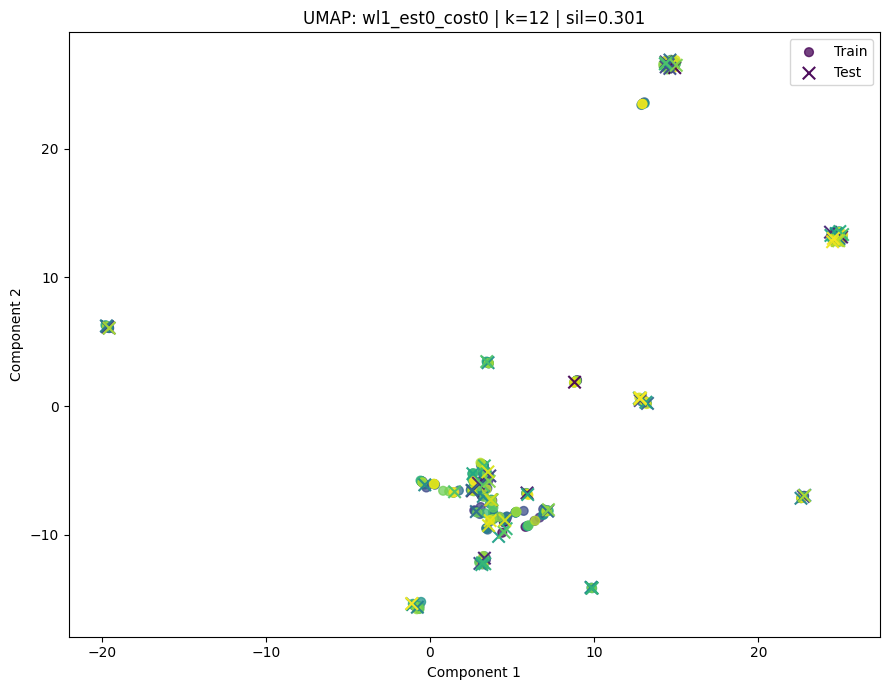


=== Evaluating wl1_est1_cost0 ===
Selected k=6


/opt/miniconda3/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


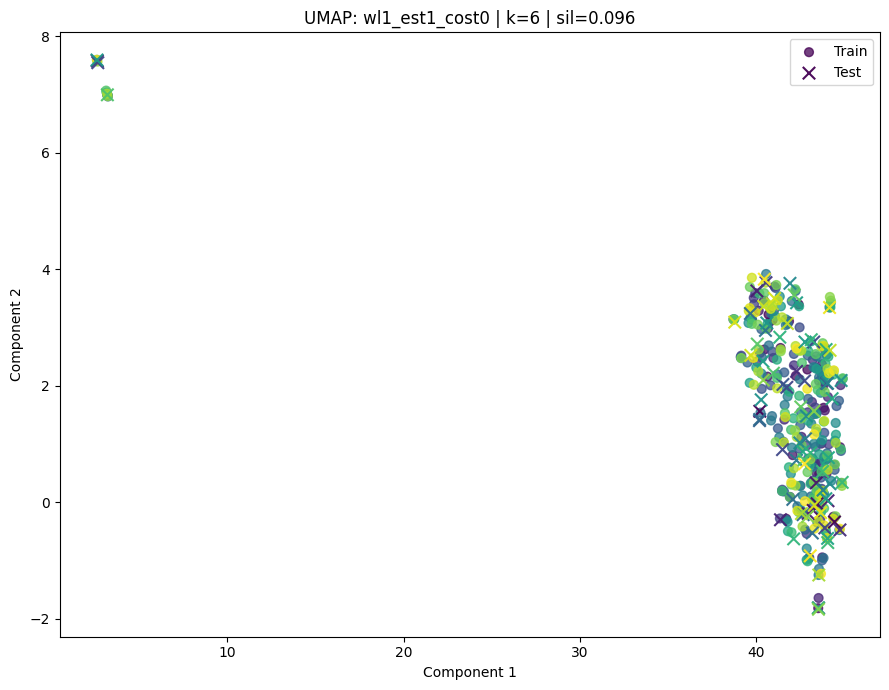


=== Evaluating wl1_est1_cost1 ===
Selected k=8


/opt/miniconda3/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


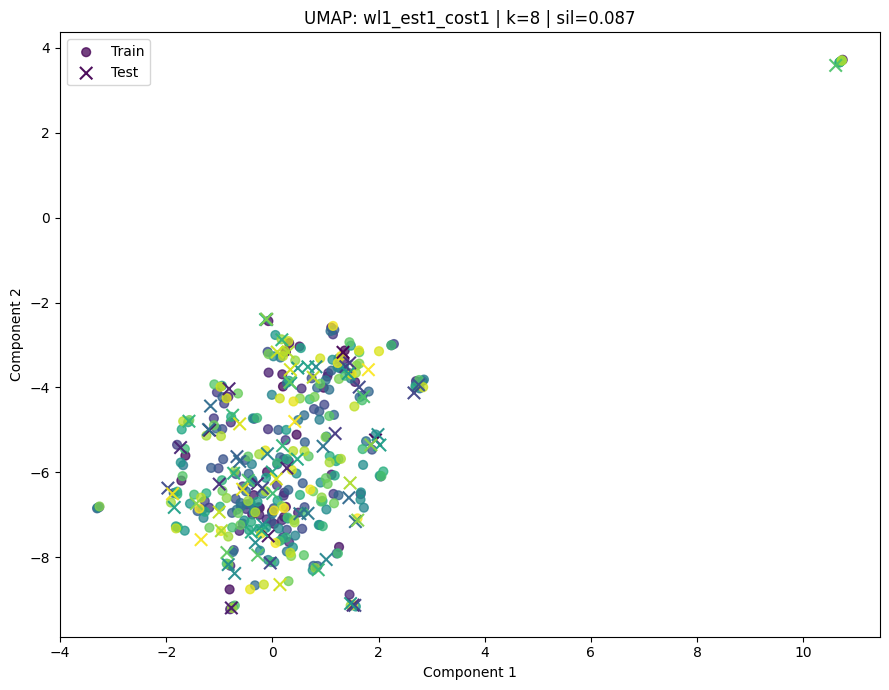


=== Evaluating wl2_est0_cost0 ===
Selected k=12


/opt/miniconda3/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/miniconda3/lib/python3.10/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(


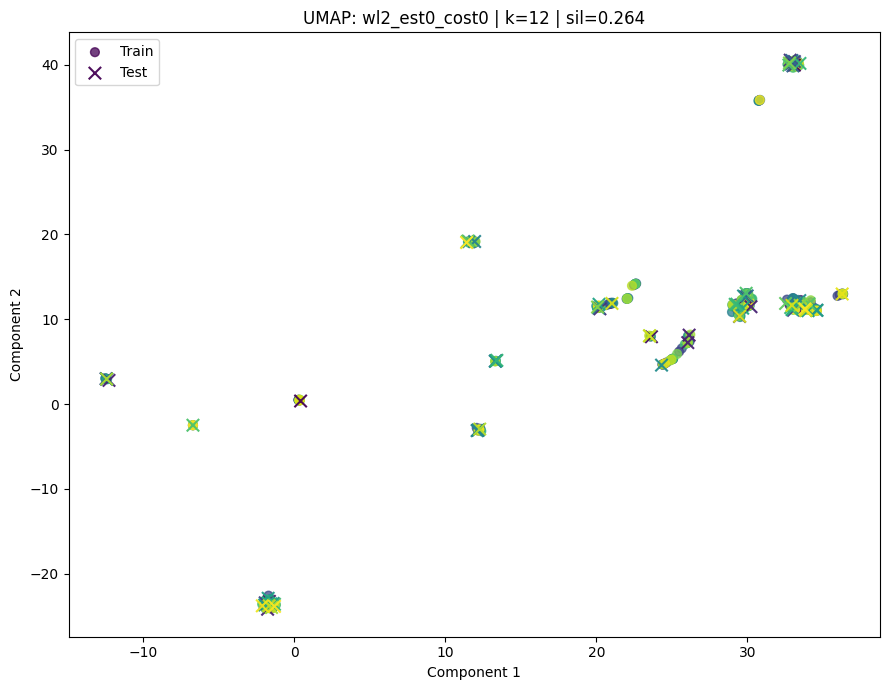


=== Evaluating wl2_est1_cost0 ===
Selected k=6


/opt/miniconda3/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


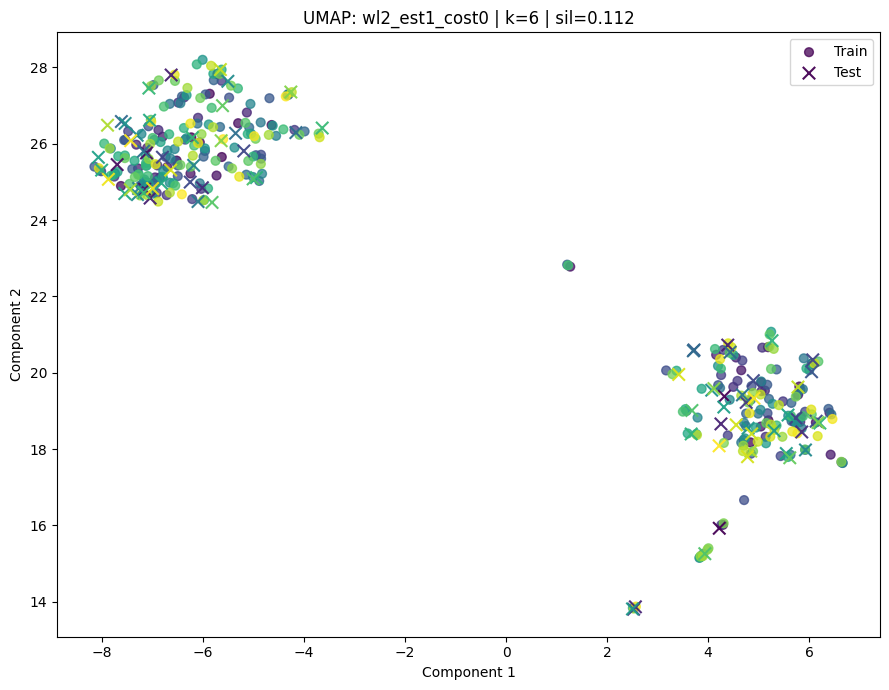


=== Evaluating wl2_est1_cost1 ===
Selected k=12


/opt/miniconda3/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


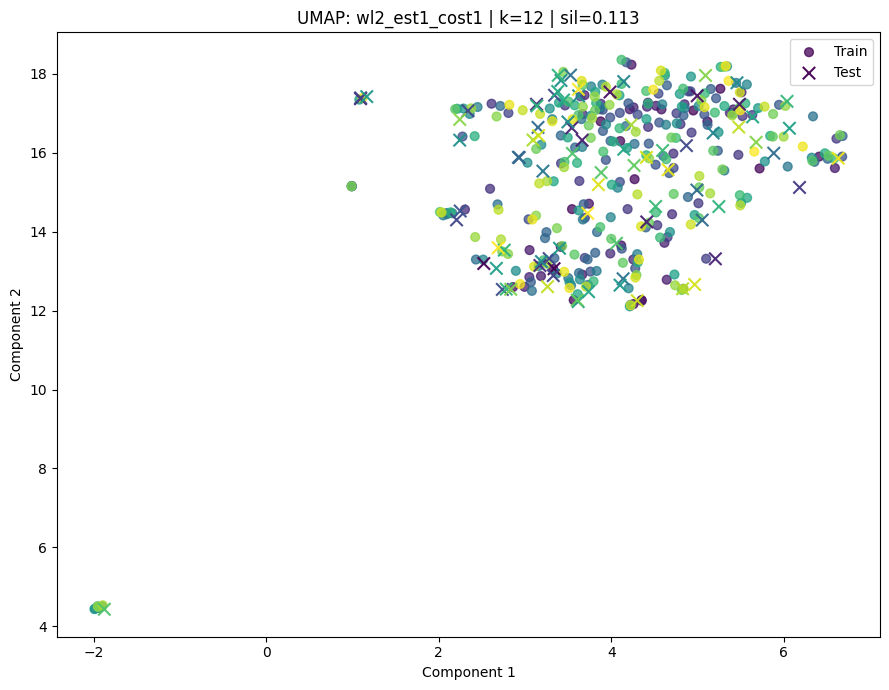


=== Evaluating wl4_est0_cost0 ===
Selected k=12


/opt/miniconda3/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/miniconda3/lib/python3.10/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(


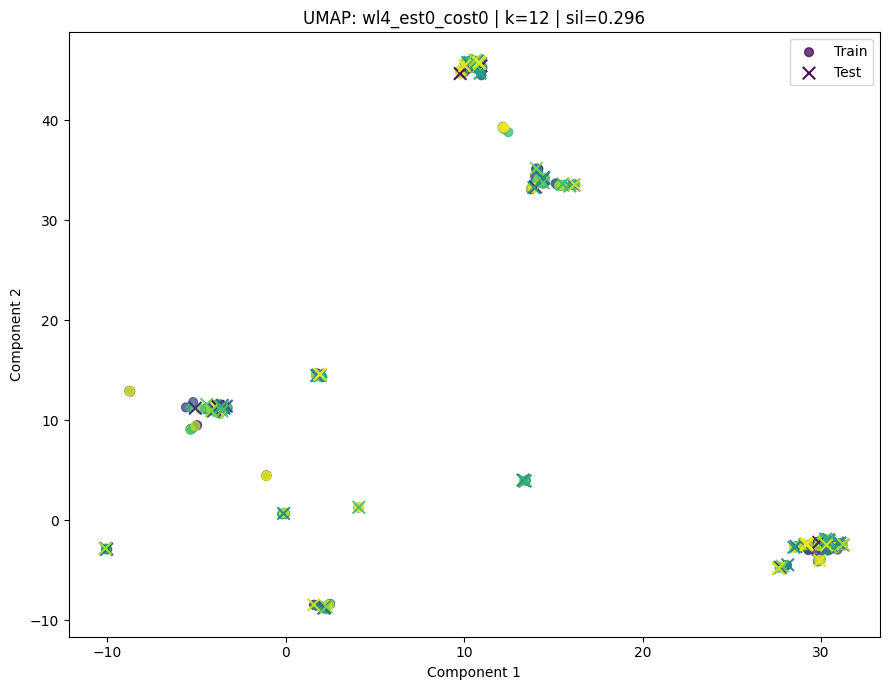


=== Evaluating wl4_est1_cost0 ===
Selected k=8


/opt/miniconda3/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


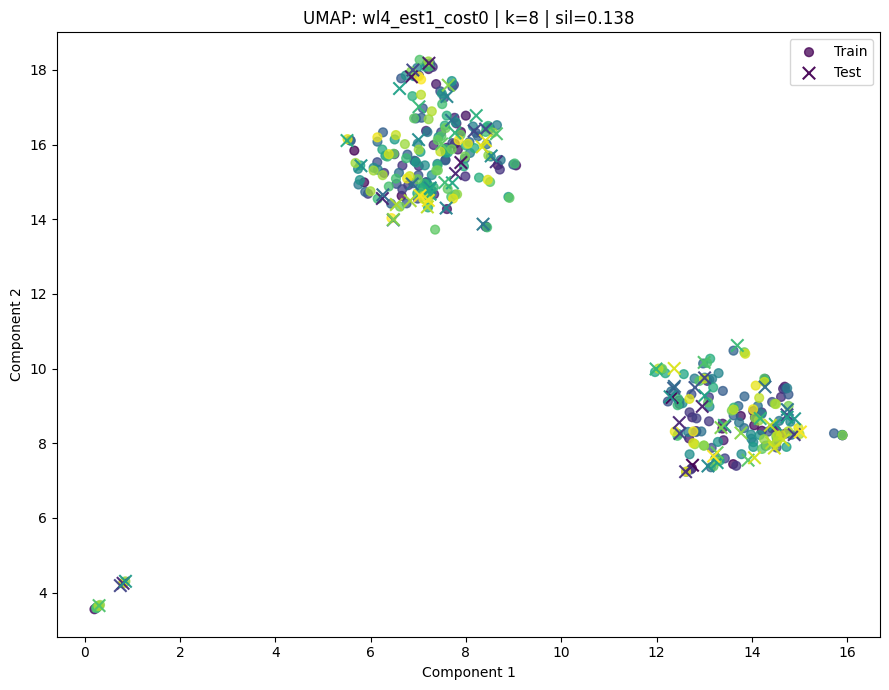


=== Evaluating wl4_est1_cost1 ===
Selected k=10


/opt/miniconda3/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


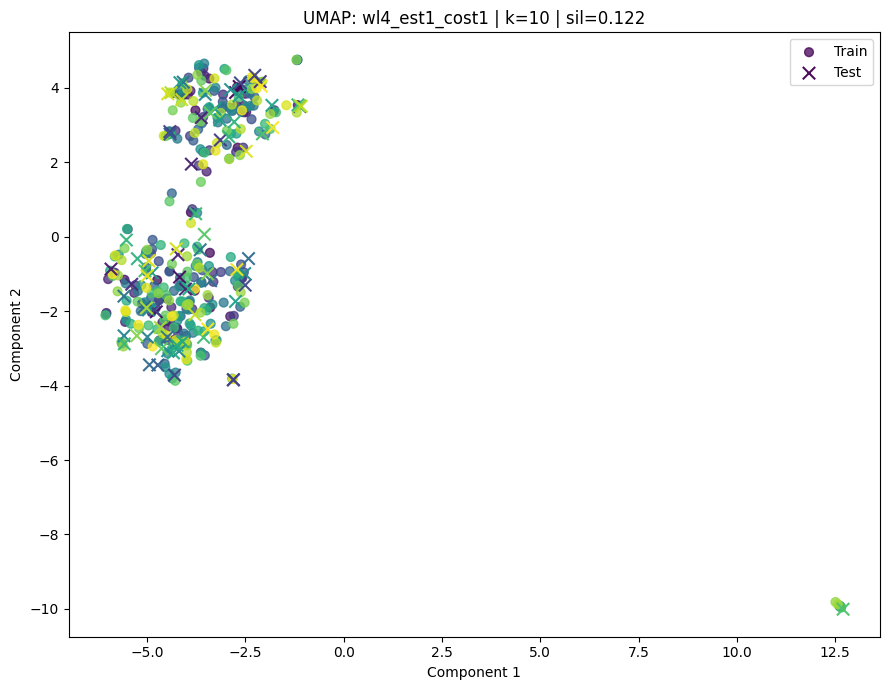

     setting_name  n_iter  use_estimates  use_cost_estimates   k  \
3  wl2_est0_cost0       2          False               False  12   
1  wl1_est1_cost0       1           True               False   6   
6  wl4_est0_cost0       4          False               False  12   
7  wl4_est1_cost0       4           True               False   8   
8  wl4_est1_cost1       4           True                True  10   
4  wl2_est1_cost0       2           True               False   6   
2  wl1_est1_cost1       1           True                True   8   
5  wl2_est1_cost1       2           True                True  12   
0  wl1_est0_cost0       1          False               False  12   

   train_silhouette  train_davies_bouldin  train_calinski_harabasz  \
3          0.264490              1.834015                15.651680   
1          0.095565              3.074805                 8.959541   
6          0.295964              1.920813                17.454491   
7          0.138204              2.4935

In [19]:
results_df, detailed_df = evaluate_wl_embeddings(
    plans_by_query=plans_by_query,
    train_qids=train_qids,
    test_qids=test_qids,
    family_fn=default_family_fn,   # replace if needed
    emb_dim=256,
    include_edge_types=True,
    direction="both",
    standardise=True,
    out_dir="./wl_embedding_eval",
)

print(results_df.sort_values(
    ["frac_test_inside_cluster_radius", "train_silhouette"],
    ascending=[False, False]
))


In [19]:
from __future__ import annotations

from collections import defaultdict
from typing import Any, Dict, List, Optional, Tuple

import networkx as nx
import numpy as np
import pandas as pd

# Assumes these already exist in your environment:
# - trino_dag_dict_to_nx
# - plans_by_query : Dict[str, dict]


def dag_to_nx(dag) -> nx.DiGraph:
    if isinstance(dag, nx.DiGraph):
        return dag
    return trino_dag_dict_to_nx(dag)


def compute_plan_depth(G: nx.DiGraph) -> Optional[int]:
    if len(G.nodes) == 0:
        return None
    if nx.is_directed_acyclic_graph(G):
        try:
            return nx.dag_longest_path_length(G)
        except Exception:
            return None
    return None


def coarse_plan_signature(
    dag,
    *,
    include_estimates: bool = True,
) -> Tuple:
    """
    Build a deterministic structural signature for a plan.

    Two plans will be grouped together if they have the same:
      - node count
      - edge count
      - DAG depth
      - multiset of operator names
      - multiset of fragment ids
      - optional estimate-bin multisets

    This deliberately ignores schema/table/column identifiers.
    """
    G = dag_to_nx(dag)

    op_counts = defaultdict(int)
    frag_counts = defaultdict(int)
    est_bins_rc = defaultdict(int)
    est_bins_sz = defaultdict(int)

    for _, d in G.nodes(data=True):
        op = str(d.get("op", d.get("name", "UNK")))
        op_counts[op] += 1

        frag = d.get("fragment", None)
        if frag is not None:
            frag_counts[str(frag)] += 1

        if include_estimates:
            # support either flattened node attrs or nested estimates list
            # flattened attrs
            for k, ctr in [("outputRowCount", est_bins_rc), ("outputSizeInBytes", est_bins_sz)]:
                v = d.get(k, None)
                try:
                    fv = float(v)
                    if np.isfinite(fv):
                        b = int(np.floor(np.log10(max(fv, 1.0))))
                        ctr[f"{k}:10^{b}"] += 1
                except Exception:
                    pass

            # nested estimate dicts if present
            est_list = d.get("estimates", [])
            if isinstance(est_list, list):
                for est in est_list:
                    if not isinstance(est, dict):
                        continue
                    for k, ctr in [("outputRowCount", est_bins_rc), ("outputSizeInBytes", est_bins_sz)]:
                        v = est.get(k, None)
                        try:
                            fv = float(v)
                            if np.isfinite(fv):
                                b = int(np.floor(np.log10(max(fv, 1.0))))
                                ctr[f"{k}:10^{b}"] += 1
                        except Exception:
                            pass

    sig = (
        G.number_of_nodes(),
        G.number_of_edges(),
        compute_plan_depth(G),
        tuple(sorted(op_counts.items())),
        tuple(sorted(frag_counts.items())),
        tuple(sorted(est_bins_rc.items())) if include_estimates else (),
        tuple(sorted(est_bins_sz.items())) if include_estimates else (),
    )
    return sig


def find_structurally_identical_groups(
    plans_by_query: Dict[str, Any],
    *,
    qids: Optional[List[str]] = None,
    include_estimates: bool = True,
    min_group_size: int = 2,
) -> List[List[str]]:
    """
    Return groups of qids whose plans have identical structural signatures.
    """
    if qids is None:
        qids = sorted(plans_by_query.keys())

    groups = defaultdict(list)
    for q in qids:
        sig = coarse_plan_signature(plans_by_query[q], include_estimates=include_estimates)
        groups[sig].append(q)

    out = [sorted(v) for v in groups.values() if len(v) >= min_group_size]
    out = sorted(out, key=lambda g: (-len(g), g))
    return out


def structural_diversity_report(
    plans_by_query: Dict[str, Any],
    *,
    qids: Optional[List[str]] = None,
    include_estimates: bool = True,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Summary + detail tables for structural diversity.
    """
    if qids is None:
        qids = sorted(plans_by_query.keys())

    sig_to_qids = defaultdict(list)
    for q in qids:
        sig = coarse_plan_signature(plans_by_query[q], include_estimates=include_estimates)
        sig_to_qids[sig].append(q)

    group_sizes = [len(v) for v in sig_to_qids.values()]
    n_total = sum(group_sizes)
    n_unique = len(group_sizes)
    n_repeated_groups = sum(1 for s in group_sizes if s > 1)
    n_queries_in_repeated_groups = sum(s for s in group_sizes if s > 1)

    summary_df = pd.DataFrame([{
        "n_total_queries": n_total,
        "n_unique_structures": n_unique,
        "n_repeated_structure_groups": n_repeated_groups,
        "n_queries_in_repeated_groups": n_queries_in_repeated_groups,
        "pct_queries_in_repeated_groups": 100.0 * n_queries_in_repeated_groups / max(n_total, 1),
        "max_group_size": max(group_sizes) if group_sizes else 0,
        "mean_group_size": float(np.mean(group_sizes)) if group_sizes else 0.0,
        "median_group_size": float(np.median(group_sizes)) if group_sizes else 0.0,
    }])

    detail_rows = []
    for sig, qids_ in sig_to_qids.items():
        detail_rows.append({
            "group_size": len(qids_),
            "qids": sorted(qids_),
        })

    detail_df = (
        pd.DataFrame(detail_rows)
        .sort_values("group_size", ascending=False)
        .reset_index(drop=True)
    )

    return summary_df, detail_df

In [20]:
struct_groups = find_structurally_identical_groups(
    plans_by_query,
    include_estimates=True,
    min_group_size=2,
)

print(f"Found {len(struct_groups)} repeated structural groups")
for g in struct_groups[:20]:
    print(g)

summary_df, detail_df = structural_diversity_report(
    plans_by_query,
    include_estimates=True,
)

print(summary_df.to_string(index=False))
print(detail_df.head(20).to_string(index=False))

Found 27 repeated structural groups
['q13', 'q133', 'q143', 'q169', 'q229', 'q242', 'q342', 'q351', 'q355', 'q371', 'q39', 'q420', 'q428', 'q484', 'q85']
['q114', 'q262', 'q288', 'q337', 'q360', 'q426', 'q477', 'q489']
['q12', 'q227', 'q343', 'q412', 'q439']
['q156', 'q28', 'q326', 'q482', 'q88']
['q183', 'q191', 'q233', 'q25', 'q410']
['q194', 'q290', 'q307', 'q309', 'q357']
['q112', 'q204', 'q395', 'q463']
['q179', 'q217', 'q293', 'q464']
['q185', 'q263', 'q374', 'q73']
['q186', 'q300', 'q415', 'q83']
['q139', 'q354', 'q429']
['q145', 'q188', 'q87']
['q10', 'q100']
['q132', 'q71']
['q175', 'q492']
['q214', 'q250']
['q240', 'q434']
['q280', 'q42']
['q30', 'q335']
['q308', 'q486']
 n_total_queries  n_unique_structures  n_repeated_structure_groups  n_queries_in_repeated_groups  pct_queries_in_repeated_groups  max_group_size  mean_group_size  median_group_size
             415                  347                           27                            95                       22.891566 